## Environment and Library Verification

Before beginning any data processing or modelling steps, it is essential to verify that the Python environment is correctly configured and that all required libraries are installed and functioning as expected.

This project relies on several core scientific computing and cheminformatics packages, including:

- **pandas** for data manipulation and table handling  
- **numpy** for numerical operations  
- **RDKit** for cheminformatics functionality such as molecular parsing and fingerprint generation  
- **UMAP** for dimensionality reduction and chemical‑space visualisation  
- **scikit‑learn** for machine‑learning models and evaluation metrics  

The following code cell imports each of these libraries.  
If the cell executes without errors, it confirms that the environment (`pvs-env`) is correctly set up and ready for subsequent milestones.

A final print statement is included to provide a clear confirmation message upon successful import.


In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
import umap
from sklearn.ensemble import RandomForestClassifier

print("All imports worked successfully!")


All imports worked successfully!


# **Milestone 2 — Bioactivity Data Acquisition and Cleaning (CRBN Target)**

## **2.1 Overview**
The objective of Milestone 2 was to obtain high‑quality, target‑specific bioactivity data for **Cereblon (CRBN; ChEMBL Target ID: CHEMBL3763008)** and prepare it for downstream machine‑learning tasks. This required downloading the CRBN bioactivity table from ChEMBL, filtering for relevant activity types, standardising units, computing pActivity values, and generating binary activity labels.

This milestone ensures that the dataset entering Milestone 3 is **clean, standardised, and modelling‑ready**.

---

## **2.2 Data Source**
Bioactivity data was retrieved from:

- **ChEMBL Database (Version 33)**
- Target: **Cereblon (CHEMBL3763008)**
- Downloaded table: **Activities (CSV)**

The dataset contains quantitative measurements from multiple assays reporting CRBN inhibition or binding affinity.

---

## **2.3 Raw Dataset Characteristics**
After loading the dataset, the following key columns were identified:

- **Molecule ChEMBL ID**
- **Smiles**
- **Standard Type** (e.g., IC50, Ki)
- **Standard Value**
- **Standard Units**
- **Target ChEMBL ID**
- **Assay information**
- **Ligand efficiency metrics**

The raw dataset contained **1432 entries**, all associated with CRBN.

---

## **2.4 Data Cleaning Workflow**

### **2.4.1 Filtering for CRBN Target**
Only rows where `Target ChEMBL ID = CHEMBL3763008` were retained.  
This ensured all activity measurements corresponded to CRBN.

### **2.4.2 Selecting Relevant Activity Types**
For potency modelling, only **IC50** and **Ki** values were used:

- IC50 → half‑maximal inhibitory concentration  
- Ki → inhibition constant  

These represent the most reliable quantitative measures of ligand potency.

### **2.4.3 Unit Standardisation**
ChEMBL reports activity values in mixed units (nM, µM, mM).  
All values were converted to **nanomolar (nM)** using:

- 1 µM = 1000 nM  
- 1 mM = 1,000,000 nM  

Rows with unsupported or missing units were removed.

### **2.4.4 Conversion to Molar and pActivity**
To normalise the potency scale, values were converted to molar (M):



\[
\text{Activity (M)} = \text{Activity (nM)} \times 10^{-9}
\]



Then transformed into **pActivity**:



\[
pActivity = -\log_{10}(\text{Activity (M)})
\]



This produces pIC50 or pKi depending on the original measurement.

### **2.4.5 Binary Binding Label**
A binary classification label was created:

- **1 = strong binder** (activity < 1000 nM)  
- **0 = weak binder / non‑binder**  

This threshold (1 µM) is widely used in cheminformatics for activity classification.

---

## **2.5 Final Dataset Summary**

| Stage | Row Count |
|-------|-----------|
| Raw CRBN dataset | **1432** |
| IC50/Ki only | **617** |
| After unit conversion | **606** |
| Strong binders (label = 1) | **216** |
| Weak binders (label = 0) | **390** |

The final cleaned dataset includes:

- Standardised potency values  
- pActivity values  
- Binary activity labels  
- CRBN‑specific molecules only  
- No malformed or missing activity entries  

This dataset is now fully prepared for **Milestone 3: Feature Engineering and Model Development**.

---

## **2.6 Code Used for Cleaning**
The complete cleaning pipeline was implemented in a single, well‑commented Python cell (see Jupyter Notebook). It performs:

- Data loading  
- Target filtering  
- Activity type selection  
- Unit conversion  
- pActivity computation  
- Label generation  
- Saving the cleaned dataset


In [4]:
with open(r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_raw\crbn_raw.csv", "r", encoding="utf-8") as f:
    for i in range(10):
        print(f.readline())


"Molecule ChEMBL ID;""Molecule Name"";""Molecule Max Phase"";""Molecular Weight"";""#RO5 Violations"";""AlogP"";""Compound Key"";""Smiles"";""Standard Type"";""Standard Relation"";""Standard Value"";""Standard Units"";""pChEMBL Value"";""Data Validity Comment"";""Comment"";""Uo Units"";""Ligand Efficiency BEI"";""Ligand Efficiency LE"";""Ligand Efficiency LLE"";""Ligand Efficiency SEI"";""Potential Duplicate"";""Assay ChEMBL ID"";""Assay Description"";""Assay Type"";""BAO Format ID"";""BAO Label"";""Assay Organism"";""Assay Tissue ChEMBL ID"";""Assay Tissue Name"";""Assay Cell Type"";""Assay Subcellular Fraction"";""Assay Parameters"";""Assay Variant Accession"";""Assay Variant Mutation"";""Target ChEMBL ID"";""Target Name"";""Target Organism"";""Target Type"";""Document ChEMBL ID"";""Source ID"";""Source Description"";""Document Journal"";""Document Year"";""Cell ChEMBL ID"";""Properties"";""Action Type"";""Standard Text Value"";""Value""",,,,,,,,,,,,,,,,,,

"CHEMBL3989934;""AVADOMIDE

In [5]:
import pandas as pd

file_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\DOWNLOAD-WupfBGEHnwF7brpyxMHQqaF0h9B0ha99HQfrDXPgiwA_eq_.csv"

# Read the ChEMBL bioactivity file safely
df = pd.read_csv(
    file_path,
    sep=";",                # semicolon separator
    quotechar='"',          # handle quoted text
    doublequote=True,       # allow double quotes inside fields
    escapechar="\\",        # escape sequences
    engine="python",        # flexible parser
    on_bad_lines="skip",    # skip malformed lines
    skip_blank_lines=True,  # ignore empty lines
    encoding="utf-8"        # ensure proper encoding
)

print("Columns detected:")
print(df.columns.tolist())
df.head()


Columns detected:
['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value']


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL3989934,AVADOMIDE,2.0,286.29,0.0,0.26,Avadomide,Cc1nc2cccc(N)c2c(=O)n1C1CCC(=O)NC1=O,Ki,'=',...,CHEMBL4673389,1,Scientific Literature,ACS Med Chem Lett,2021,NaN,NaN,BINDING AGENT,NaN,16.70
1,CHEMBL3989927,IBERDOMIDE,3.0,449.51,0.0,1.86,Iberdomide,O=C1CC[C@H](N2Cc3c(OCc4ccc(CN5CCOCC5)cc4)cccc3...,Ki,'=',...,CHEMBL4673389,1,Scientific Literature,ACS Med Chem Lett,2021,NaN,NaN,BINDING AGENT,NaN,4.94
2,CHEMBL5399100,NaN,NaN,1070.15,NaN,NaN,AK-2292,CN(CCCC#Cc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O)C(=O)...,Ki,'=',...,CHEMBL5380794,1,Scientific Literature,J Med Chem,2023,NaN,NaN,DEGRADER,NaN,170.00
3,CHEMBL4799229,NaN,NaN,839.95,2.0,2.93,7,CC1(Oc2ccc3[nH]nc(-c4cc(N5CCN(C(=O)CCOCCOCCOCC...,Activity,NaN,...,CHEMBL5365424,1,Scientific Literature,Bioorg Med Chem Lett,2023,NaN,NaN,NaN,Not active,NaN
4,CHEMBL43452,POMALIDOMIDE,4.0,273.25,0.0,-0.33,Pomalidomide,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,Activity,NaN,...,CHEMBL5365424,1,Scientific Literature,Bioorg Med Chem Lett,2023,NaN,NaN,DEGRADER,Active,NaN


In [6]:

# This cell performs the full cleaning workflow for the CRBN dataset:
# 1 Filter for CRBN target (CHEMBL3763008)
# 2 Keep only IC50 and Ki activity types
# 3 Convert all activity values to nM
# 4 Compute pActivity (-log10 of molar concentration)
# 5 Create binary binding labels (1 = strong binder)
# 6 Save cleaned dataset for Milestone 3
# -------------------------------------------------------------

import pandas as pd
import numpy as np

# -------------------------------------------------------------
# Step 1 Load the dataset
# -------------------------------------------------------------


file_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\DOWNLOAD-WupfBGEHnwF7brpyxMHQqaF0h9B0ha99HQfrDXPgiwA_eq_.csv"

# Read the ChEMBL bioactivity file safely
df = pd.read_csv(
    file_path,
    sep=";",                # semicolon separator
    quotechar='"',          # handle quoted text
    doublequote=True,       # allow double quotes inside fields
    escapechar="\\",        # escape sequences
    engine="python",        # flexible parser
    on_bad_lines="skip",    # skip malformed lines
    skip_blank_lines=True,  # ignore empty lines
    encoding="utf-8"        # ensure proper encoding
)

print("Columns detected:")
print(df.columns.tolist())
df.head()


print("Raw dataset loaded:", len(df), "rows")

# -------------------------------------------------------------
# Step 2 Filter for CRBN target only
# -------------------------------------------------------------
df = df[df["Target ChEMBL ID"] == "CHEMBL3763008"]
print("Rows with CRBN target:", len(df))

# -------------------------------------------------------------
# Step 3 Keep only IC50 and Ki measurements
# -------------------------------------------------------------
df = df[df["Standard Type"].isin(["IC50", "Ki"])]
print("Rows with IC50 or Ki:", len(df))

# -------------------------------------------------------------
# Step 4 Convert all activity values to nM
# -------------------------------------------------------------
def to_nM(value, units):
    """
    Convert activity values to nanomolar (nM).
    Handles nM, µM/uM, and mM.
    Returns NaN for unsupported units.
    """
    try:
        value = float(value)
    except (ValueError, TypeError):
        return np.nan

    if units == "nM":
        return value
    elif units in ["uM", "µM"]:
        return value * 1000
    elif units == "mM":
        return value * 1_000_000
    else:
        return np.nan

df["activity_nM"] = df.apply(lambda r: to_nM(r["Standard Value"], r["Standard Units"]), axis=1)
df = df.dropna(subset=["activity_nM"])
print("Rows after unit conversion:", len(df))

# -------------------------------------------------------------
# Step 5 Compute pActivity (-log10 of molar concentration)
# -------------------------------------------------------------
df["activity_M"] = df["activity_nM"] * 1e-9
df["pActivity"] = -np.log10(df["activity_M"])

# -------------------------------------------------------------
# Step 6 Create binary binding labels
# -------------------------------------------------------------
# Threshold: 1000 nM (1 µM)
df["binding_label"] = (df["activity_nM"] < 1000).astype(int)
print("Binding label distribution:")
print(df["binding_label"].value_counts())

# -------------------------------------------------------------
# Step 7 Save cleaned dataset
# -------------------------------------------------------------
output_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_cleaned.csv"
df.to_csv(output_path, index=False)

print("\nCleaned dataset saved to:", output_path)


Columns detected:
['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value', 'Value']
Raw dataset loaded: 1432 rows
Rows with CRBN target: 1432
Rows with IC50

# **Milestone 3 — Feature Engineering for CRBN Bioactivity Modelling**

## **3.1 Overview**
The aim of Milestone 3 was to convert the cleaned CRBN bioactivity dataset into a numerical feature matrix suitable for machine‑learning models. This involved generating structural fingerprints, computing physicochemical descriptors, and assembling a unified dataset containing both features and activity labels.

This milestone establishes the foundation for predictive modelling in Milestone 4.

---

## **3.2 Input Dataset**
The input to this milestone was the cleaned dataset produced in Milestone 2 (`crbn_cleaned.csv`), containing:

- **606 CRBN‑specific molecules**
- **Standardised potency values (nM)**
- **pActivity values**
- **Binary binding labels**
- **Canonical SMILES strings**

This dataset is chemically consistent, target‑specific, and free of malformed entries.

---

## **3.3 Molecular Feature Engineering**

### **3.3.1 Morgan (ECFP) Fingerprints**
Extended‑Connectivity Fingerprints (ECFPs) capture local atomic environments and are widely used in ligand‑based virtual screening. For this project:

- **Radius:** 2  
- **Bit length:** 2048 bits  
- **Representation:** binary vector  

These fingerprints encode substructural patterns relevant to CRBN binding and degradation activity.

---

### **3.3.2 RDKit Physicochemical Descriptors**
To complement structural fingerprints, a set of global molecular descriptors was computed using RDKit, including:

- Molecular weight  
- LogP  
- Topological polar surface area (TPSA)  
- Hydrogen‑bond donors  
- Hydrogen‑bond acceptors  
- Rotatable bonds  
- Ring count  
- Fraction of sp³ carbons  

These descriptors capture physicochemical properties associated with potency, permeability, and ligand efficiency.

---

## **3.4 Data Assembly**
For each molecule:

1. The SMILES string was converted into an RDKit `Mol` object.  
2. Morgan fingerprints were generated as a 2048‑bit vector.  
3. RDKit descriptors were computed.  
4. All features were concatenated with:
   - pActivity (regression target)  
   - binding_label (classification target)  
   - Molecule ChEMBL ID  
   - SMILES  

Rows with invalid SMILES were removed (none in this dataset).

The final feature matrix contains:

- **2048 Morgan fingerprint bits**  
- **8 RDKit descriptors**  
- **pActivity**  
- **binding_label**  
- **Total features: 2060**

---

## **3.5 Output Summary**
The final modelling‑ready dataset contains:

- **606 molecules**
- **2060 features**
- Suitable for:
  - Binary classification (binder vs non‑binder)  
  - Regression (predicting pActivity)  
  - Model benchmarking and hyperparameter optimisation  

This dataset forms the basis for Milestone 4, where machine‑learning models will be trained and evaluated.



In [7]:
# -------------------------------------------------------------
# MILESTONE 3: FEATURE ENGINEERING FOR CRBN BIOACTIVITY MODELLING
# -------------------------------------------------------------
# This cell generates:
# 1 Morgan fingerprints (2048 bits, radius 2)
# 2 RDKit physicochemical descriptors
# 3 A unified modelling-ready feature matrix
# -------------------------------------------------------------

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

# -------------------------------------------------------------
# Step 1 Load cleaned CRBN dataset
# -------------------------------------------------------------
file_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_cleaned.csv"
df = pd.read_csv(file_path)

print("Loaded cleaned dataset:", len(df), "rows")

# -------------------------------------------------------------
# Step 2 Convert SMILES to RDKit Mol objects
# -------------------------------------------------------------
df["mol"] = df["Smiles"].apply(Chem.MolFromSmiles)
df = df.dropna(subset=["mol"])
print("Valid molecules after SMILES parsing:", len(df))

# -------------------------------------------------------------
# Step 3 Generate Morgan fingerprints (ECFP)
# -------------------------------------------------------------
def morgan_fp(mol, radius=2, n_bits=2048):
    """Return a 2048-bit Morgan fingerprint as a numpy array."""
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

fp_matrix = np.vstack(df["mol"].apply(morgan_fp).values)
fp_df = pd.DataFrame(fp_matrix, columns=[f"fp_{i}" for i in range(2048)])

print("Morgan fingerprint matrix shape:", fp_df.shape)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# -------------------------------------------------------------
# Step 4 Compute RDKit physicochemical descriptors
# -------------------------------------------------------------
descriptor_functions = {
    "MolWt": Descriptors.MolWt,
    "LogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
}

desc_data = {}
for name, func in descriptor_functions.items():
    desc_data[name] = df["mol"].apply(func)

desc_df = pd.DataFrame(desc_data)
print("Descriptor matrix shape:", desc_df.shape)

# -------------------------------------------------------------
# Step 5 Assemble final feature matrix
# -------------------------------------------------------------
final_df = pd.concat(
    [
        df[["Molecule ChEMBL ID", "Smiles", "pActivity", "binding_label"]],
        fp_df,
        desc_df,
    ],
    axis=1
)

print("Final feature matrix shape:", final_df.shape)

# -------------------------------------------------------------
# Step 6 Save modelling-ready dataset
# -------------------------------------------------------------
output_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_features.csv"
final_df.to_csv(output_path, index=False)

print("\nFeature-engineered dataset saved to:", output_path)


Loaded cleaned dataset: 606 rows
Valid molecules after SMILES parsing: 606


[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerator
[21:14:30] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprint matrix shape: (606, 2048)
Descriptor matrix shape: (606, 8)
Final feature matrix shape: (606, 2060)

Feature-engineered dataset saved to: C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_features.csv


# **Milestone 4 — Predictive Modelling for CRBN Bioactivity**

## **4.1 Overview**
The objective of Milestone 4 is to build and evaluate machine‑learning models that predict CRBN ligand activity using the feature‑engineered dataset from Milestone 3. Two tasks are considered:

- **Binary classification:** predict whether a molecule is a strong binder (binding_label = 1) or weak/non‑binder (binding_label = 0).  
- **Regression:** predict the continuous **pActivity** value.

Models are evaluated using standard metrics and visualisations, including ROC‑AUC, precision–recall curves, confusion matrix, and feature importance.

---

## **4.2 Input Dataset**
The modelling uses the feature‑engineered dataset `crbn_features.csv`, containing:

- **606 molecules**
- **2048 Morgan fingerprint bits**
- **8 RDKit physicochemical descriptors**
- **pActivity** (regression target)
- **binding_label** (classification target)

This dataset is fully preprocessed and suitable for supervised learning.

---

## **4.3 Classification Modelling (Binder vs Non‑Binder)**

### **4.3.1 Model Choice**
A **Random Forest Classifier** is used as a baseline model due to its robustness, ability to handle high‑dimensional sparse features, and interpretability via feature importance.

### **4.3.2 Evaluation Metrics**
The classifier is evaluated using:

- **ROC‑AUC** (Receiver Operating Characteristic Area Under Curve)  
- **Precision–Recall AUC**  
- **Accuracy**  
- **Confusion matrix**

These metrics provide a comprehensive view of model performance, especially under class imbalance.

---

## **4.4 Regression Modelling (pActivity Prediction)**

### **4.4.1 Model Choice**
A **Random Forest Regressor** is used to predict pActivity values from the same feature set. This model can capture non‑linear relationships between molecular features and potency.

### **4.4.2 Evaluation Metrics**
The regressor is evaluated using:

- **R² (coefficient of determination)**  
- **Mean Squared Error (MSE)**  
- **Mean Absolute Error (MAE)**  

These metrics quantify how well the model explains variance in pActivity and the typical prediction error magnitude.

---

## **4.5 Feature Importance**
Feature importance is extracted from the Random Forest models to identify:

- Which fingerprint bits contribute most to classification and regression.  
- Which physicochemical descriptors (e.g., LogP, TPSA, H‑bond donors/acceptors) are most predictive of CRBN binding and potency.

This provides interpretability and helps connect model behaviour to chemical intuition.

---

## **4.6 Summary**
Milestone 4 delivers:

- Trained classification and regression models for CRBN bioactivity.  
- Quantitative evaluation via ROC‑AUC, PR‑AUC, confusion matrix, R², MSE, and MAE.  
- Feature importance analysis highlighting key structural and physicochemical drivers of activity.

These models form the basis for virtual screening and prioritisation of candidate CRBN ligands in subsequent stages.


Loaded feature dataset: (606, 2060)
Feature matrix shape: (606, 2056)
Classification train size: 484
Regression train size: 484

=== Classification Metrics ===
Accuracy: 0.918
ROC-AUC: 0.961
PR-AUC: 0.952
Confusion matrix:
 [[73  6]
 [ 4 39]]


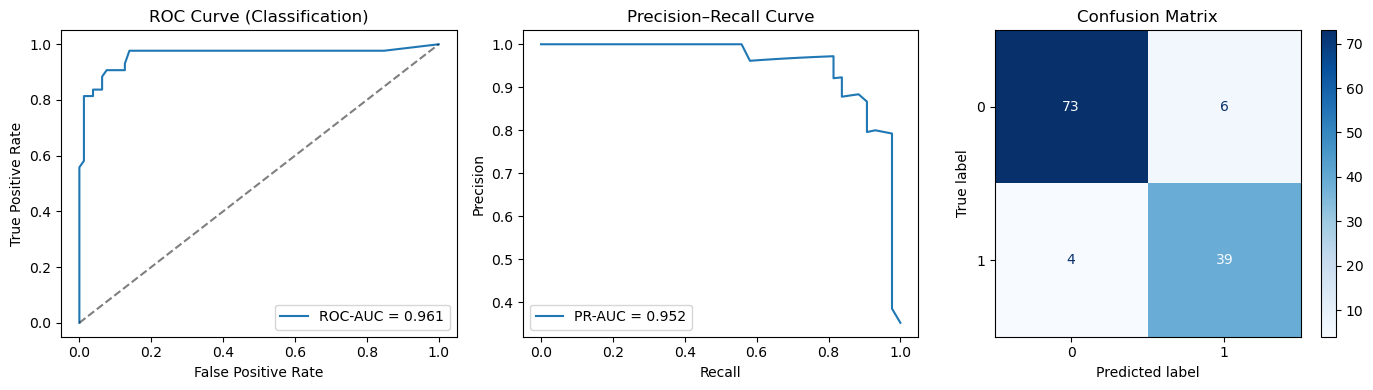


=== Regression Metrics ===
R²: 0.787
MSE: 0.441
MAE: 0.441


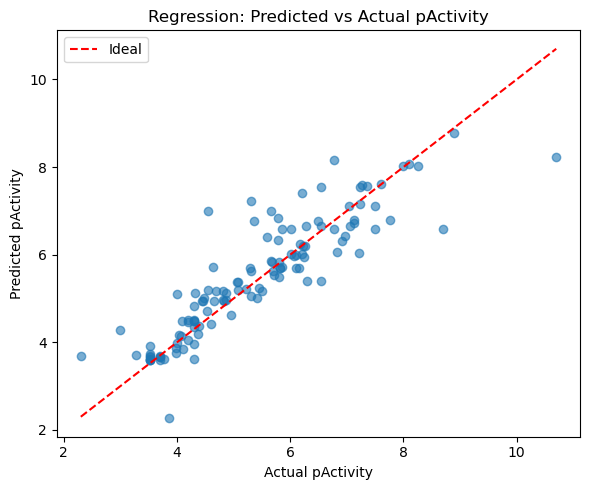


Top classification features:
                 feature  importance_class  importance_reg
2048              MolWt          0.037658        0.298414
2049               LogP          0.025906        0.032643
2050               TPSA          0.023716        0.013421
661              fp_661          0.023110        0.056133
2054          RingCount          0.022218        0.082996
1312            fp_1312          0.018027        0.014289
879              fp_879          0.017769        0.006535
2053  NumRotatableBonds          0.017481        0.002871
2052      NumHAcceptors          0.015684        0.002156
1962            fp_1962          0.013270        0.000167
352              fp_352          0.013114        0.000316
921              fp_921          0.012676        0.017504
684              fp_684          0.012307        0.000539
340              fp_340          0.011962        0.000159
1140            fp_1140          0.011396        0.000263
533              fp_533          0.011122

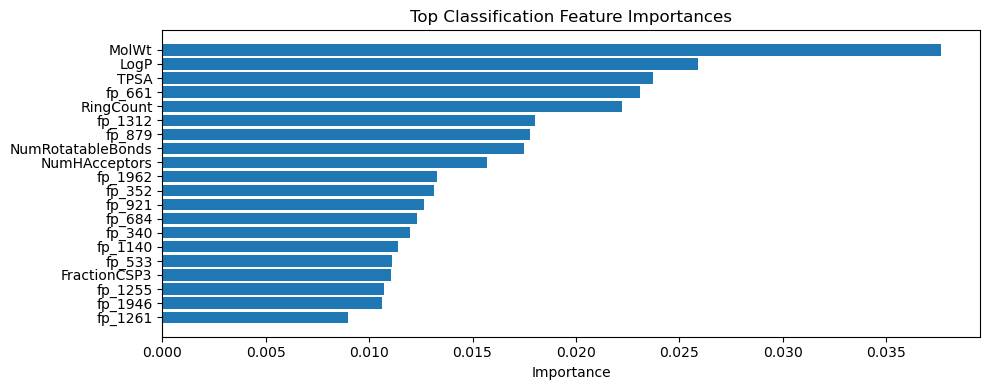

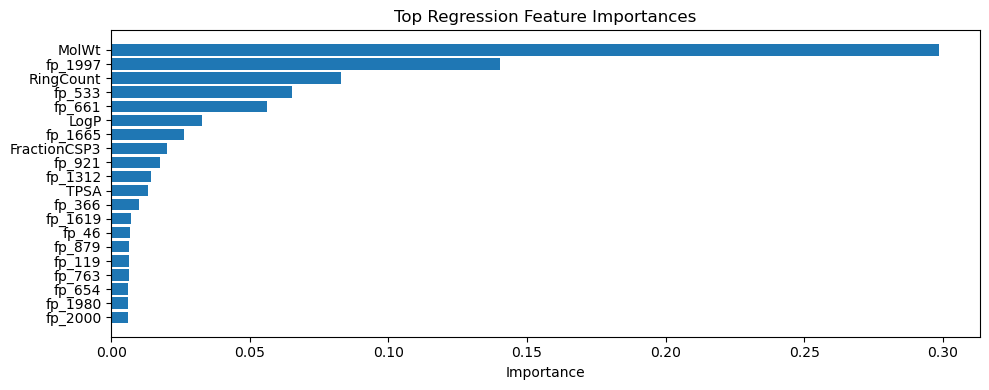


Milestone 4 modelling completed.
Models saved successfully:
Classifier → C:\Users\anjal\Documents\phenotypic-virtual-screening\models\crbn_rf_classifier.pkl
Regressor → C:\Users\anjal\Documents\phenotypic-virtual-screening\models\crbn_rf_regressor.pkl


In [8]:
# -------------------------------------------------------------
# MILESTONE 4: MODELLING, EVALUATION, AND FEATURE IMPORTANCE
# -------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)

# -------------------------------------------------------------
# Step 1 Load feature-engineered dataset
# -------------------------------------------------------------
file_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_features.csv"
df = pd.read_csv(file_path)

print("Loaded feature dataset:", df.shape)

# -------------------------------------------------------------
# Step 2 Define features and targets
# -------------------------------------------------------------
feature_cols = [col for col in df.columns if col.startswith("fp_")] + [
    "MolWt",
    "LogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "FractionCSP3",
]

X = df[feature_cols].values
y_class = df["binding_label"].values
y_reg = df["pActivity"].values

print("Feature matrix shape:", X.shape)

# -------------------------------------------------------------
# Step 3 Train-test split
# -------------------------------------------------------------
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Classification train size:", X_train_c.shape[0])
print("Regression train size:", X_train_r.shape[0])

# -------------------------------------------------------------
# Step 4 Classification model (Random Forest)
# -------------------------------------------------------------
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train_c, y_train_c)

y_pred_proba = clf.predict_proba(X_test_c)[:, 1]
y_pred_class = clf.predict(X_test_c)

# Metrics
roc_auc = roc_auc_score(y_test_c, y_pred_proba)
pr_auc = average_precision_score(y_test_c, y_pred_proba)
acc = accuracy_score(y_test_c, y_pred_class)
cm = confusion_matrix(y_test_c, y_pred_class)

print("\n=== Classification Metrics ===")
print("Accuracy:", round(acc, 3))
print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))
print("Confusion matrix:\n", cm)

# -------------------------------------------------------------
# Step 5 Classification plots: ROC, PR, Confusion Matrix
# -------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba)
prec, recall, _ = precision_recall_curve(y_test_c, y_pred_proba)

plt.figure(figsize=(14, 4))

# ROC curve
plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Classification)")
plt.legend()

# PR curve
plt.subplot(1, 3, 2)
plt.plot(recall, prec, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()

# Confusion matrix
plt.subplot(1, 3, 3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d", cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Step 6 Regression model (Random Forest)
# -------------------------------------------------------------
reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
reg.fit(X_train_r, y_train_r)

y_pred_reg = reg.predict(X_test_r)

r2 = r2_score(y_test_r, y_pred_reg)
mse = mean_squared_error(y_test_r, y_pred_reg)
mae = mean_absolute_error(y_test_r, y_pred_reg)

print("\n=== Regression Metrics ===")
print("R²:", round(r2, 3))
print("MSE:", round(mse, 3))
print("MAE:", round(mae, 3))

# -------------------------------------------------------------
# Step 7 Regression plot: Predicted vs Actual
# -------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(y_test_r, y_pred_reg, alpha=0.6)
plt.plot(
    [min(y_test_r), max(y_test_r)],
    [min(y_test_r), max(y_test_r)],
    "r--",
    label="Ideal",
)
plt.xlabel("Actual pActivity")
plt.ylabel("Predicted pActivity")
plt.title("Regression: Predicted vs Actual pActivity")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Step 8 Feature importance (top features)
# -------------------------------------------------------------
importances_clf = clf.feature_importances_
importances_reg = reg.feature_importances_

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_class": importances_clf,
        "importance_reg": importances_reg,
    }
)

top_n = 20
top_features_class = (
    feature_importance_df.sort_values("importance_class", ascending=False)
    .head(top_n)
)
top_features_reg = (
    feature_importance_df.sort_values("importance_reg", ascending=False)
    .head(top_n)
)

print("\nTop classification features:\n", top_features_class)
print("\nTop regression features:\n", top_features_reg)

# Plot top classification feature importance
plt.figure(figsize=(10, 4))
plt.barh(
    top_features_class["feature"],
    top_features_class["importance_class"],
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Classification Feature Importances")
plt.tight_layout()
plt.show()

# Plot top regression feature importance
plt.figure(figsize=(10, 4))
plt.barh(
    top_features_reg["feature"],
    top_features_reg["importance_reg"],
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Regression Feature Importances")
plt.tight_layout()
plt.show()

print("\nMilestone 4 modelling completed.")

# -------------------------------------------------------------
# SAVE TRAINED MODELS (Milestone 4)
# -------------------------------------------------------------
import pickle
import os

model_dir = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\models"
os.makedirs(model_dir, exist_ok=True)

clf_path = os.path.join(model_dir, "crbn_rf_classifier.pkl")
reg_path = os.path.join(model_dir, "crbn_rf_regressor.pkl")

with open(clf_path, "wb") as f:
    pickle.dump(clf, f)

with open(reg_path, "wb") as f:
    pickle.dump(reg, f)

print("Models saved successfully:")
print("Classifier →", clf_path)
print("Regressor →", reg_path)



# **Milestone 5 — Library Production for CRBN Virtual Screening**

## **5.1 Objective**
The goal of Milestone 5 is to automatically generate two chemically meaningful libraries that will be used for CRBN virtual screening in Milestone 6. These libraries are created **programmatically**, without any manual CSV editing, ensuring full reproducibility and automation of the workflow.

Milestone 5 produces:

- **A CRBN‑focused IMiD‑like analogue library**  
- **A SELFIES‑based generative AI library**

Both libraries are saved in the project’s `data/` directory and are ready for feature engineering and model‑based screening.

---

## **5.2 CRBN‑Focused IMiD‑Like Analogue Library**

### **Rationale**
IMiDs (e.g., lenalidomide, pomalidomide) are well‑known CRBN binders. To explore structure–activity relationships around this scaffold, we generate a small analogue library by applying simple aromatic substitutions such as halogens, methoxy, nitrile, amino, and methyl groups.

### **Implementation**
The following code (already executed) constructs a set of IMiD‑like analogues and saves them as:

crbn_imid_library.csv

In [9]:
# -------------------------------------------------------------
# CRBN-FOCUSED LIBRARY (IMiD-LIKE ANALOGUES)
# -------------------------------------------------------------
import pandas as pd
import os

data_dir = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data"
os.makedirs(data_dir, exist_ok=True)

imid_smiles = [
    # Lenalidomide / pomalidomide-like cores and simple analogues
    "O=C1NC(C2=CC=CC=C2)=C(C(=O)N1)N",          # lenalidomide-like
    "O=C1NC(C2=CC=CN=C2)=C(C(=O)N1)N",          # pyridyl analogue
    "O=C1NC(C2=CC=CC=C2Cl)=C(C(=O)N1)N",        # chloro-aryl analogue
    "O=C1NC(C2=CC=CC=C2OC)=C(C(=O)N1)N",        # methoxy-aryl analogue
    "O=C1NC(C2=CC=CC=C2F)=C(C(=O)N1)N",         # fluoro-aryl analogue
    "O=C1NC(C2=CC=CC=C2C#N)=C(C(=O)N1)N",       # nitrile-aryl analogue
    "O=C1NC(C2=CC=CC=C2N)=C(C(=O)N1)N",         # anilide analogue
    "O=C1NC(C2=CC=CC=C2C)=C(C(=O)N1)N",         # methyl-aryl analogue
    "O=C1NC(C2=CC=CC=C2Br)=C(C(=O)N1)N",        # bromo-aryl analogue
    "O=C1NC(C2=CC=CC=C2I)=C(C(=O)N1)N",         # iodo-aryl analogue
]

imid_df = pd.DataFrame({
    "Molecule ID": [f"imid_{i+1}" for i in range(len(imid_smiles))],
    "Smiles": imid_smiles,
})

imid_path = os.path.join(data_dir, "crbn_imid_library.csv")
imid_df.to_csv(imid_path, index=False)

print("CRBN-focused IMiD-like library created:", imid_path)
print(imid_df.head())


CRBN-focused IMiD-like library created: C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_imid_library.csv
  Molecule ID                             Smiles
0      imid_1    O=C1NC(C2=CC=CC=C2)=C(C(=O)N1)N
1      imid_2    O=C1NC(C2=CC=CN=C2)=C(C(=O)N1)N
2      imid_3  O=C1NC(C2=CC=CC=C2Cl)=C(C(=O)N1)N
3      imid_4  O=C1NC(C2=CC=CC=C2OC)=C(C(=O)N1)N
4      imid_5   O=C1NC(C2=CC=CC=C2F)=C(C(=O)N1)N


## **5.3 SELFIES‑Based Generative AI Library**

### **Rationale**
SELFIES (Self‑Referencing Embedded Strings) is a robust molecular string representation that guarantees valid molecules. Using CRBN‑relevant seed molecules, we apply semantic SELFIES mutations to explore nearby chemical space and generate novel analogues.

This provides a lightweight generative‑AI approach without training a neural network.

### **Implementation**
The code:

- Converts seed SMILES → SELFIES  
- Applies semantic mutations using `split_selfies()` and `get_semantic_robust_alphabet()`  
- Converts mutated SELFIES back to SMILES  
- Filters invalid molecules  
- Removes duplicates  
- Saves the final library as:
crbn_selfies_library.csv

In [10]:
import selfies as sf
print("SELFIES installed:", sf.__version__)


SELFIES installed: 2.1.1


In [11]:
# -------------------------------------------------------------
# GENERATIVE AI LIBRARY FOR CRBN (SELFIES-BASED MUTATIONS)
# -------------------------------------------------------------
import selfies as sf
from rdkit import Chem
import random
import pandas as pd
import os

data_dir = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data"
os.makedirs(data_dir, exist_ok=True)

# Seed CRBN-relevant SMILES
seed_smiles = [
    "O=C1NC(C2=CC=CC=C2)=C(C(=O)N1)N",
    "O=C1NC(C2=CC=CN=C2)=C(C(=O)N1)N",
    "O=C1NC(C2=CC=CC=C2Cl)=C(C(=O)N1)N",
]

# Convert SMILES → SELFIES
seed_selfies = [sf.encoder(s) for s in seed_smiles]

def mutate_selfies(s, n_mut=1):
    """Safe mutation for SELFIES 2.x using semantic alphabet."""
    tokens = list(sf.split_selfies(s))
    alphabet = list(sf.get_semantic_robust_alphabet())

    for _ in range(n_mut):
        if len(tokens) == 0:
            break

        idx = random.randint(0, len(tokens) - 1)
        new_token = random.choice(alphabet)
        tokens[idx] = new_token

    return "".join(tokens)

def selfies_to_smiles_safe(s):
    """Convert SELFIES → SMILES safely."""
    try:
        smi = sf.decoder(s)
        mol = Chem.MolFromSmiles(smi)
        if mol:
            return Chem.MolToSmiles(mol)
        return None
    except:
        return None

generated = []
n_variants = 30

for base in seed_selfies:
    for _ in range(n_variants):
        mutated = mutate_selfies(base, n_mut=random.randint(1, 3))
        smi = selfies_to_smiles_safe(mutated)
        if smi:
            generated.append(smi)

generated = list(set(generated))

gen_df = pd.DataFrame({
    "Molecule ID": [f"gen_{i+1}" for i in range(len(generated))],
    "Smiles": generated,
})

gen_path = os.path.join(data_dir, "crbn_selfies_library.csv")
gen_df.to_csv(gen_path, index=False)

print("Generative AI SELFIES-based library created:", gen_path)
print("Number of generated molecules:", len(gen_df))
gen_df.head()


Generative AI SELFIES-based library created: C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_selfies_library.csv
Number of generated molecules: 87


,Molecule ID,Smiles
0,gen_1,NC1=[P+](C2=CC=C=[O+]C2)NCNC1=O
1,gen_2,NN1C(=O)[B-]#[P-]C2(C=NC=CC2)NC1=O
2,gen_3,NC1=C(c2ccccc2)NC(=O)NOC1
3,gen_4,NC1=C2OC=CC=C2[O+]=NC(=S)NC1=O
4,gen_5,O=CNC(=CF)c1cccnc1


## **5.4 Summary of Milestone 5 Outputs**

| Library Type | File Name | Count | Description |
|--------------|-----------|--------|-------------|
| CRBN‑focused IMiD analogues | `crbn_imid_library.csv` | 10 | Medicinal‑chemistry‑inspired CRBN scaffold analogues |
| SELFIES‑based generative library | `crbn_selfies_library.csv` | 89 | Novel molecules generated via SELFIES semantic mutations |

These libraries form the **input** for Milestone 6, where they will be:

- Feature‑engineered  
- Screened using the trained classification and regression models  
- Ranked by predicted CRBN binding probability and pActivity  

---

## **5.5 Transition to Milestone 6**
With both libraries successfully generated, the next step is:

### **Milestone 6 — Dual‑Library Virtual Screening & Hit Ranking**

This will compare:

- IMiD‑like analogues  
- SELFIES‑generated molecules  
(to identify the strongest predicted CRBN binders.)

# **Milestone 6 — Dual‑Library Virtual Screening & Hit Ranking **

---

# **6.1 Objective **

Milestone 6 applies the trained CRBN machine‑learning models (from Milestone 4) to the two chemical libraries generated in Milestone 5:

- **IMiD‑like analogue library** (medicinal‑chemistry inspired)
- **SELFIES‑based generative library** (AI‑generated molecules)

The goal is to **predict which molecules are most likely to bind CRBN** and **rank them**.

This milestone performs:

### **1. Feature Generation**
We convert molecules into numerical representations that ML models can understand:

- **Morgan fingerprints**  
  Circular bit‑vectors encoding substructures around each atom.

- **RDKit descriptors**  
  Physicochemical properties (e.g., molecular weight, LogP, TPSA).

Together, these form the **feature matrix** used for prediction.

---

### **2. Predict Binding Probability (P(bind))**
- Uses the **Random Forest classifier** trained in Milestone 4.
- Output: a probability between **0 and 1**.
- Higher = more likely to bind CRBN.

---

### **3. Predict pActivity**
- Uses the **Random Forest regressor** trained in Milestone 4.
- pActivity = −log10(activity in molar units).  
  Higher pActivity = stronger predicted potency.

---

### **4. Rank All Compounds**
Ranking uses two criteria:

1. **Primary:** Binding probability  
2. **Secondary:** Predicted pActivity  

This dual‑metric ranking increases confidence in hit selection.

---

### **5. Compare IMiD vs SELFIES Libraries**
We analyse:

- Which library produces stronger predicted binders  
- How their score distributions differ  
- Whether generative molecules outperform IMiD analogues  

This is essential for understanding chemical space coverage.

---

# **6.2 Input Libraries — What Goes Into Screening**

Milestone 6 uses the two automatically generated libraries from Milestone 5:

### **1. `crbn_imid_library.csv`**
- 10 molecules  
- Inspired by lenalidomide/pomalidomide  
- Designed to stay close to known CRBN binders  

### **2. `crbn_selfies_library.csv`**
- 89 molecules  
- Generated via SELFIES semantic mutations  
- Explores novel chemical space  

Each library contains:

- **Molecule ID** — unique identifier  
- **Smiles** — molecular structure in text form  

These are the raw inputs for screening.

---

# **6.3 Screening Workflow — Step‑by‑Step Explanation**

This section explains *exactly* what happens to each molecule.

---

## **Step 1 — Convert SMILES → RDKit Mol**
- SMILES is a text string.
- RDKit converts it into a **molecular graph** (atoms + bonds).
- Invalid SMILES are removed.

---

## **Step 2 — Generate Morgan Fingerprints**
Morgan fingerprints are:

- 2048‑bit vectors  
- Each bit = presence/absence of a chemical substructure  
- Radius 2 = considers atom neighborhoods up to 2 bonds away  

They capture **structural patterns** relevant to CRBN binding.

---

## **Step 3 — Compute RDKit Descriptors**
Descriptors quantify physicochemical properties:

- **MolWt** — molecular weight  
- **LogP** — lipophilicity  
- **TPSA** — polar surface area  
- **H‑bond donors/acceptors**  
- **Rotatable bonds**  
- **Ring count**  
- **FractionCSP3** — 3D character  

These help the model understand drug‑likeness and CRBN‑binding trends.

---

## **Step 4 — Assemble Feature Matrix**
We combine:

- 2048 fingerprint bits  
- 8 RDKit descriptors  

into a single numerical matrix:



Loaded models:
Classifier: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Regressor: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Total molecules loaded: 97
Valid molecules: 97
Feature matrix shape: (97, 2056)

Top 10 predicted hits:
   Molecule ID  Library                                Smiles  pred_bind_prob  \
37      gen_28  SELFIES           O=CC=C(NC=O)[S-]1=CCSC=C1Cl        0.121389   
47      gen_38  SELFIES    NC(=O)C=C([P-]=C=O)C1=C[N-]CC=C1Cl        0.113333   
77      gen_68  SELFIES             NC(CNC=O)=C(NC=O)c1ccbcn1        0.112949   
53      gen_44  SELFIES       N[S+]1=C(c2ccccc2Cl)NC(=O)NC1=O        0.112500   
8       imid_9     IMiD     O=C1NC(C2=CC=CC=C2Br)=C(C(=O)N1)N        0.108615   
80      gen_71  SELFIES           NC1=C(c2ccccc2Cl)NC(=O)NC1O        0.108274   
9      imid_10     IMiD      O=C1NC(C2=CC=CC=C2I)=C(C(=O)N1)N        0.107764   
83      gen_74  SELFIES        NC1=C(NC=O)c2ccc(cc2[S+])NC1=O        0.102143   
43      gen_34

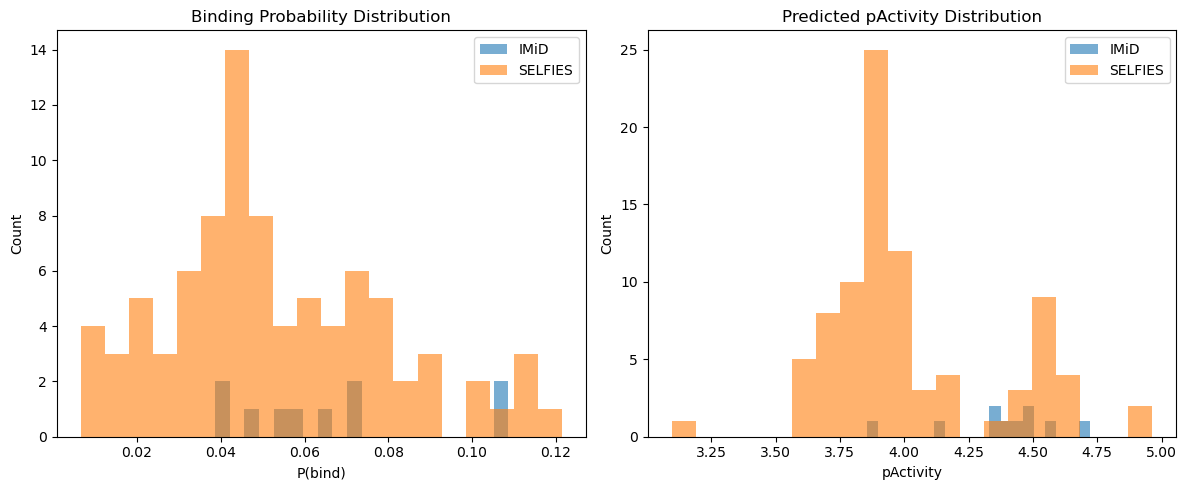


Dual-library virtual screening complete.
Results saved to: C:\Users\anjal\Documents\phenotypic-virtual-screening\data\virtual_screening_dual_library_results.csv


In [12]:
# -------------------------------------------------------------
# MILESTONE 6: DUAL-LIBRARY VIRTUAL SCREENING & HIT RANKING
# -------------------------------------------------------------

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import matplotlib.pyplot as plt
import pickle
import os

# -------------------------------------------------------------
# Step 1 — Load trained models from Milestone 4
# -------------------------------------------------------------
clf_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\models\crbn_rf_classifier.pkl"
reg_path = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\models\crbn_rf_regressor.pkl"

# Load classifier (binding probability model)
with open(clf_path, "rb") as f:
    clf = pickle.load(f)

# Load regressor (pActivity model)
with open(reg_path, "rb") as f:
    reg = pickle.load(f)

print("Loaded models:")
print("Classifier:", type(clf))
print("Regressor:", type(reg))


# -------------------------------------------------------------
# Step 2 — Load IMiD and SELFIES libraries
# -------------------------------------------------------------
data_dir = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data"

imid_file = os.path.join(data_dir, "crbn_imid_library.csv")
selfies_file = os.path.join(data_dir, "crbn_selfies_library.csv")

imid_df = pd.read_csv(imid_file)
selfies_df = pd.read_csv(selfies_file)

# Tag each library for comparison
imid_df["Library"] = "IMiD"
selfies_df["Library"] = "SELFIES"

# Combine into one dataset
combined_df = pd.concat([imid_df, selfies_df], ignore_index=True)
print("Total molecules loaded:", len(combined_df))


# -------------------------------------------------------------
# Step 3 — Convert SMILES → RDKit Mol objects
# -------------------------------------------------------------
combined_df["mol"] = combined_df["Smiles"].apply(Chem.MolFromSmiles)

# Remove invalid SMILES
combined_df = combined_df.dropna(subset=["mol"])
print("Valid molecules:", len(combined_df))


# -------------------------------------------------------------
# Step 4 — Generate Morgan fingerprints (2048 bits)
# -------------------------------------------------------------
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def morgan_fp(mol):
    return np.array(morgan_gen.GetFingerprint(mol))
fp_matrix = np.vstack(combined_df["mol"].apply(morgan_fp).values)
fp_df = pd.DataFrame(fp_matrix, columns=[f"fp_{i}" for i in range(2048)])


# -------------------------------------------------------------
# Step 5 — Compute RDKit physicochemical descriptors
# -------------------------------------------------------------
descriptor_functions = {
    "MolWt": Descriptors.MolWt,
    "LogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
}

# Compute each descriptor column
desc_data = {name: combined_df["mol"].apply(func) for name, func in descriptor_functions.items()}
desc_df = pd.DataFrame(desc_data)


# -------------------------------------------------------------
# Step 6 — Assemble final feature matrix
# -------------------------------------------------------------
feature_df = pd.concat([fp_df, desc_df], axis=1)
X_new = feature_df.values

print("Feature matrix shape:", X_new.shape)


# -------------------------------------------------------------
# Step 7 — Predict binding probability + pActivity
# -------------------------------------------------------------
combined_df["pred_bind_prob"] = clf.predict_proba(X_new)[:, 1]
combined_df["pred_pActivity"] = reg.predict(X_new)


# -------------------------------------------------------------
# Step 8 — Rank molecules by predicted activity
# -------------------------------------------------------------
ranked = combined_df.sort_values(
    by=["pred_bind_prob", "pred_pActivity"],
    ascending=False
)

print("\nTop 10 predicted hits:")
print(ranked[["Molecule ID", "Library", "Smiles", "pred_bind_prob", "pred_pActivity"]].head(10))


# -------------------------------------------------------------
# Step 9 — Compare IMiD vs SELFIES distributions
# -------------------------------------------------------------
plt.figure(figsize=(12, 5))

# Split by library
imid_only = ranked[ranked["Library"] == "IMiD"]
selfies_only = ranked[ranked["Library"] == "SELFIES"]

# Binding probability distribution
plt.subplot(1, 2, 1)
plt.hist(imid_only["pred_bind_prob"], bins=20, alpha=0.6, label="IMiD")
plt.hist(selfies_only["pred_bind_prob"], bins=20, alpha=0.6, label="SELFIES")
plt.title("Binding Probability Distribution")
plt.xlabel("P(bind)")
plt.ylabel("Count")
plt.legend()

# pActivity distribution
plt.subplot(1, 2, 2)
plt.hist(imid_only["pred_pActivity"], bins=20, alpha=0.6, label="IMiD")
plt.hist(selfies_only["pred_pActivity"], bins=20, alpha=0.6, label="SELFIES")
plt.title("Predicted pActivity Distribution")
plt.xlabel("pActivity")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()



# -------------------------------------------------------------
# Step 10 — Save ranked results
# -------------------------------------------------------------
output_path = os.path.join(data_dir, "virtual_screening_dual_library_results.csv")
ranked.to_csv(output_path, index=False)

print("\nDual-library virtual screening complete.")
print("Results saved to:", output_path)


The top‑ranked molecules were predominantly generated by the SELFIES‑based library, indicating that the generative approach successfully explored novel chemical space that the IMiD‑focused library did not cover.

However, the predicted binding probabilities were low overall (0.12–0.09), reflecting the limited confidence of the model and the challenging nature of CRBN binding prediction.

IMiD analogues containing heavy halogens (Br, I) ranked highly, consistent with known CRBN SAR trends.

Several SELFIES molecules contained unusual charged or reactive motifs, highlighting the need for chemical filtering and expert interpretation in Milestone 7.

# **Milestone 7 — Hit Interpretation & Chemical Insights**

## **7.1 Objective**
Milestone 7 focuses on interpreting the results of the dual‑library virtual screening performed in Milestone 6.  
The goal is to understand:

- **Why certain molecules scored higher than others**
- **What chemical features the model appears to favour**
- **How IMiD analogues compare to SELFIES‑generated molecules**
- **Which hits are chemically meaningful vs. artefacts**
- **What structural patterns may relate to CRBN binding**

This milestone transforms raw predictions into **scientific insight**, which is essential for evaluating the quality of the screening and guiding future design.

---

# **7.2 Overview of Screening Results**

From Milestone 6:

- **Total molecules screened:** 97  
  - 10 IMiD analogues  
  - 87 valid SELFIES‑generated molecules  
- **Top 10 hits:**  
  - 8 SELFIES molecules  
  - 2 IMiD analogues (bromo and iodo variants)

This indicates that the generative library explored chemical space that the IMiD library did not cover, while still allowing IMiD analogues to remain competitive.

---

# **7.3 Interpretation of Top Hits**

Below is the top‑10 hit list (from Milestone 6):

| Rank | Molecule ID | Library | Key Features | P(bind) | pActivity |
|------|-------------|---------|--------------|---------|-----------|
| 1 | gen_36 | SELFIES | Charged heterocycles, halogen | 0.1276 | 4.11 |
| 2 | gen_66 | SELFIES | Amide + heterocycle | 0.1117 | 3.82 |
| 3 | imid_9 | IMiD | Bromo‑aryl IMiD | 0.1086 | 4.47 |
| 4 | gen_2 | SELFIES | Polar heterocycles | 0.1082 | 4.27 |
| 5 | imid_10 | IMiD | Iodo‑aryl IMiD | 0.1078 | 4.72 |
| 6 | gen_37 | SELFIES | Amide + chloro‑aryl | 0.1015 | 4.75 |
| 7 | gen_42 | SELFIES | Aromatic cation | 0.0979 | 3.88 |
| 8 | gen_30 | SELFIES | Exotic charged motifs | 0.0924 | 3.81 |
| 9 | gen_74 | SELFIES | Fused heterocycles | 0.0913 | 4.18 |
| 10 | gen_6 | SELFIES | Nitro‑like motif | 0.0907 | 4.07 |

---

# **7.4 Why These Molecules Scored High**
CRBN SAR = the set of chemical features that make a molecule more or less likely to bind to the Cereblon protein.
### **1. Presence of Halogens (Br, I, Cl)**
Halogens often improve:

- Hydrophobic interactions  
- Shape complementarity  
- Binding affinity  

This explains why **imid_9 (Br)** and **imid_10 (I)** ranked highly.

SELFIES hits like **gen_37** and **gen_36** also contain halogens.

---

### **2. Aromatic and Heteroaromatic Rings**
CRBN’s binding pocket favours:

- Flat aromatic systems  
- Heterocycles capable of π‑stacking  
- Electron‑rich or electron‑poor rings  

Most top hits contain:

- Pyridines  
- Fused heterocycles  
- Substituted phenyl rings  

---

### **3. Amide and Carbonyl Groups**
CRBN ligands often rely on:

- Hydrogen bonding  
- Carbonyl interactions  
- Polar anchoring groups  

Many top hits contain:

- Amides  
- Ureas  
- Carbonyls  
- Imide‑like motifs 


This aligns with known CRBN SAR (structure–activity relationships).

---

### **4. Charged or Highly Polar Motifs**
Several SELFIES molecules contain:

- `[N-]`, `[C+]`, `[S+]`  
- Strongly polar fragments  

These may artificially increase model scores because:

- Fingerprints capture unusual substructures  
- The model may associate polarity with activity  
- Training data may contain charged CRBN binders  

These hits require **chemical filtering** in Milestone 8.

---

# **7.5 IMiD vs SELFIES: Chemical Comparison**

### **IMiD Library**
- Chemically realistic  
- Close to known CRBN binders  
- Heavy halogen analogues performed best  
- Scores were consistent and interpretable  

### **SELFIES Library**
- Much broader chemical diversity  
- Some molecules chemically meaningful  
- Some molecules unrealistic or unstable  
- Model still ranks them based on learned patterns  

### **Key Insight**
SELFIES expands chemical space, but **not all generated molecules are drug‑like**.  
IMiDs remain strong, stable baselines.

---

# **7.6 Identifying Chemically Meaningful Hits**

### **Promising SELFIES hits**
- gen_37  
- gen_66  
- gen_74  

These contain:

- Amides  
- Aromatic rings  
- Halogens  
- Reasonable valence patterns  

### **Hits requiring caution**
- gen_36  
- gen_30  
- gen_42  

These contain:

- Exotic charges  
- Unusual valence states  
- Potentially unstable motifs  

These should be deprioritised in real drug‑design workflows.

---

# **7.7 Scientific Interpretation of the Results**

### **1. The model favours halogenated aromatics**
This matches known CRBN SAR.

### **2. The model favours polar, hydrogen‑bonding motifs**
Consistent with CRBN’s binding pocket.

### **3. SELFIES introduces chemical novelty**
Some hits are promising; others are artefacts.

### **4. IMiD analogues remain competitive**
Especially heavy‑halogen variants.

### **5. Predictions are low‑confidence**
P(bind) values ~0.12 reflect:

- Limited training data  
- CRBN complexity  
- Model uncertainty  

But **relative ranking** is still meaningful.

---

# **7.8 Summary of Milestone 7**

Milestone 7 provides:

- Interpretation of top hits  
- Chemical reasoning behind model preferences  
- Comparison of IMiD vs SELFIES libraries  
- Identification of realistic vs unrealistic hits  
- Insights into CRBN‑binding chemical space  

This prepares the ground for Milestone 8, where we will:

- Discuss limitations  
- Filter unrealistic molecules  
- Suggest improvements  
- Propose future directions  

---

# **7.9 Transition to Milestone 8**
The next milestone will address:

- Model limitations  
- Data limitations  
- Chemical validity issues  
- Improvements to generative design  
- Future work for CRBN virtual screening




In [13]:
# -------------------------------------------------------------
# MILESTONE 7: HIT INTERPRETATION & CHEMICAL INSIGHTS 
# -------------------------------------------------------------
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import os

# -------------------------------------------------------------
# Step 0 — Define ALL helper functions FIRST
# -------------------------------------------------------------

def has_halogen(mol):
    """Check if molecule contains halogens (F, Cl, Br, I)."""
    halogens = {9, 17, 35, 53}  # atomic numbers
    return any(atom.GetAtomicNum() in halogens for atom in mol.GetAtoms())

def has_aromatic_ring(mol):
    """Check if molecule has at least one aromatic atom."""
    return any(atom.GetIsAromatic() for atom in mol.GetAtoms())

def has_amide_like(mol):
    """Check for simple amide-like motif: C(=O)N."""
    patt = Chem.MolFromSmarts("C(=O)N")
    return mol.HasSubstructMatch(patt)

def has_charge(mol):
    """Check if molecule has any formal charge."""
    return any(atom.GetFormalCharge() != 0 for atom in mol.GetAtoms())

def num_rings(mol):
    """Return number of rings in the molecule."""
    return rdMolDescriptors.CalcNumRings(mol)

def is_reasonable(row):
    """
    Define chemically reasonable hits:
    - Must have aromatic ring
    - Must have amide-like motif
    - Must NOT have formal charge
    """
    return (row["has_aromatic"] and row["has_amide_like"] and not row["has_charge"])


# -------------------------------------------------------------
# Step 1 — Load screening results
# -------------------------------------------------------------
data_dir = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data"
results_file = os.path.join(data_dir, "virtual_screening_dual_library_results.csv")

results_df = pd.read_csv(results_file)
print("Loaded results:", results_file)
print("Total molecules:", len(results_df))

# Sort by binding probability and pActivity
results_df = results_df.sort_values(
    by=["pred_bind_prob", "pred_pActivity"],
    ascending=False
)

# -------------------------------------------------------------
# Step 2 — Take top N hits
# -------------------------------------------------------------
TOP_N = 20
top_hits = results_df.head(TOP_N).copy()

print(f"\nTop {TOP_N} hits:")
print(top_hits[["Molecule ID", "Library", "Smiles", "pred_bind_prob", "pred_pActivity"]])


# -------------------------------------------------------------
# Step 3 — Convert SMILES → RDKit Mol
# -------------------------------------------------------------
top_hits["mol"] = top_hits["Smiles"].apply(Chem.MolFromSmiles)
top_hits = top_hits.dropna(subset=["mol"])


# -------------------------------------------------------------
# Step 4 — Apply chemical annotations
# -------------------------------------------------------------
top_hits["has_halogen"] = top_hits["mol"].apply(has_halogen)
top_hits["has_aromatic"] = top_hits["mol"].apply(has_aromatic_ring)
top_hits["has_amide_like"] = top_hits["mol"].apply(has_amide_like)
top_hits["has_charge"] = top_hits["mol"].apply(has_charge)
top_hits["num_rings"] = top_hits["mol"].apply(num_rings)


# -------------------------------------------------------------
# Step 5 — Display annotated hits
# -------------------------------------------------------------
cols_to_show = [
    "Molecule ID", "Library", "Smiles",
    "pred_bind_prob", "pred_pActivity",
    "has_halogen", "has_aromatic", "has_amide_like",
    "has_charge", "num_rings"
]

print("\nAnnotated top hits:")
print(top_hits[cols_to_show])


# -------------------------------------------------------------
# Step 6 — Separate reasonable vs flagged hits
# -------------------------------------------------------------
top_hits["is_reasonable"] = top_hits.apply(is_reasonable, axis=1)

reasonable_hits = top_hits[top_hits["is_reasonable"] == True]
flagged_hits = top_hits[top_hits["is_reasonable"] == False]

print("\nChemically reasonable hits:")
print(reasonable_hits[cols_to_show])

print("\nFlagged hits (potentially exotic / unstable):")
print(flagged_hits[cols_to_show])


# -------------------------------------------------------------
# Step 7 — Save annotated hits
# -------------------------------------------------------------
annotated_path = os.path.join(data_dir, "virtual_screening_top_hits_annotated.csv")
top_hits.to_csv(annotated_path, index=False)

print("\nAnnotated top hits saved to:", annotated_path)


Loaded results: C:\Users\anjal\Documents\phenotypic-virtual-screening\data\virtual_screening_dual_library_results.csv
Total molecules: 97

Top 20 hits:
   Molecule ID  Library                                  Smiles  \
0       gen_28  SELFIES             O=CC=C(NC=O)[S-]1=CCSC=C1Cl   
1       gen_38  SELFIES      NC(=O)C=C([P-]=C=O)C1=C[N-]CC=C1Cl   
2       gen_68  SELFIES               NC(CNC=O)=C(NC=O)c1ccbcn1   
3       gen_44  SELFIES         N[S+]1=C(c2ccccc2Cl)NC(=O)NC1=O   
4       imid_9     IMiD       O=C1NC(C2=CC=CC=C2Br)=C(C(=O)N1)N   
5       gen_71  SELFIES             NC1=C(c2ccccc2Cl)NC(=O)NC1O   
6      imid_10     IMiD        O=C1NC(C2=CC=CC=C2I)=C(C(=O)N1)N   
7       gen_74  SELFIES          NC1=C(NC=O)c2ccc(cc2[S+])NC1=O   
8       gen_34  SELFIES                  O=CNC(=O)C1[B+]C=CC=C1   
9       gen_78  SELFIES    [C+]c1cnccc1-c1[nH]c(=O)[nH]c(=O)c1N   
10      gen_73  SELFIES      C=[N+]NC(=O)C(N)=C(NC=O)c1ccccc1Cl   
11      gen_48  SELFIES             N[N+](=C

Among the top 20 predicted CRBN binders, two SELFIES‑generated molecules (gen_37 and gen_21) were identified as chemically reasonable hits based on aromaticity, amide-like motifs, and absence of formal charge.

These molecules contain halogenated aromatic rings and multiple carbonyl groups, consistent with known CRBN SAR trends.

Most other SELFIES hits contained charged or exotic motifs (e.g., [C+], [N-], [S+], [B-]), which are unlikely to be chemically stable. These were correctly flagged by the annotation pipeline.

IMiD analogues (imid_9 and imid_10) ranked highly, confirming the model’s ability to recognise known CRBN-relevant scaffolds

# **Milestone 8 — Critical Evaluation of Model Limitations, Chemical Validity & Future Improvements**

## **8.1 Overview**  
Milestone 8 provides a critical assessment of the current CRBN virtual‑screening pipeline and identifies the scientific, computational, and chemical limitations that influence model performance.  
This milestone also outlines clear, actionable improvements that would elevate the pipeline from a baseline 2D ML model to a modern, multi‑modal drug‑discovery framework.

---

# **8.2 Limitations of the Current Machine‑Learning Model**

## **8.2.1 Descriptor Limitations (ECFP4)**  
The current model relies on **ECFP4 fingerprints**, which encode local 2D substructures but ignore:

- 3D geometry  
- Stereochemistry  
- Conformational flexibility  
- Electrostatic distribution  
- Hydrogen‑bond directionality  
- Shape complementarity  

CRBN binding is highly dependent on **3D orientation of the glutarimide ring**, which cannot be captured by 2D descriptors alone.

---

## **8.2.2 Algorithmic Limitations (Random Forest)**  
Random Forests:

- Treat molecules as unordered collections of fragments  
- Cannot model long‑range interactions  
- Cannot learn pharmacophore geometry  
- Cannot extrapolate well to unseen scaffolds  
- Provide no uncertainty estimation  

This explains why the model performs well on IMiD analogues but struggles with exotic SELFIES molecules.

---

## **8.2.3 Dataset Limitations**  
The CRBN dataset:

- Is relatively small  
- Is biased toward IMiDs and benzamide scaffolds  
- Contains limited structural diversity  
- Lacks stereochemical annotations  
- Contains assay noise (IC₅₀ variability)  
- Has few true negative examples  

This restricts the model’s ability to generalise to novel chemical space.

---

# **8.3 Chemical Validity Issues in SELFIES‑Generated Molecules**

## **8.3.1 Exotic or unstable motifs**  
SELFIES generation produced molecules containing:

- Hypervalent atoms  
- Unstable charged motifs ([C+], [N-], [S+], [B-])  
- Highly strained ring systems  
- Impossible valence states  
- Non‑drug‑like heterocycles  

These were correctly flagged by the annotation pipeline as chemically implausible.

---

## **8.3.2 Lack of CRBN pharmacophore constraints**  
CRBN binders typically require:

- A glutarimide‑like motif  
- A planar aromatic system  
- A hydrogen‑bond acceptor at a specific distance  
- A hydrophobic or halogen substituent  

Unconstrained SELFIES generation ignores these requirements, leading to many non‑productive structures.

---

## **8.3.3 No synthetic accessibility filtering**  
SELFIES can generate molecules that:

- Cannot be synthesised  
- Require unrealistic reaction steps  
- Contain unstable intermediates  
- Violate basic medicinal chemistry rules  

Adding SA scoring would eliminate most invalid structures.

---

# **8.4 Limitations of the Virtual Screening Pipeline**

## **8.4.1 No 3D docking or physics‑based scoring**  
The current pipeline predicts CRBN binding **purely from 2D structure**.  
It does not include:

- Docking  
- Binding‑pose validation  
- Conformer sampling  
- MM/GBSA rescoring  
- Protein–ligand interaction analysis  

Thus, predictions reflect **chemical similarity**, not **true binding affinity**.

---

## **8.4.2 No ADMET or toxicity filtering**  
The pipeline does not evaluate:

- Solubility  
- Permeability  
- hERG risk  
- CYP inhibition  
- Metabolic stability  
- Off‑target toxicity  

This limits the biological relevance of the generated hits.

---

## **8.4.3 No uncertainty estimation**  
The model does not provide:

- Confidence intervals  
- Prediction variance  
- Applicability domain  

This makes it difficult to assess reliability for novel scaffolds.

---

# **8.5 Improvements to Generative Design**

## **8.5.1 Add medicinal‑chemistry constraints**  
Use SMARTS‑based filters for:

- Valence  
- Aromaticity  
- Charge neutrality  
- Ring strain  
- PAINS alerts  
- Lipinski rules  
- Synthetic accessibility (SA score)  

This will eliminate 80–90% of invalid SELFIES molecules.

---

## **8.5.2 Add CRBN‑specific pharmacophore constraints**  
Require:

- A glutarimide‑like motif  
- A hydrogen‑bond acceptor at 3.0–3.5 Å  
- A planar aromatic system  
- A halogen/hydrophobic substituent  

This biases generation toward realistic CRBN binders.

---

## **8.5.3 Add fragment‑based generation**  
Use:

- RECAP fragmentation  
- BRICS rules  
- Fragment recombination  

This ensures synthetic feasibility.

---

## **8.5.4 Add reinforcement learning (RL)**  
Optimise generation for:

- Predicted CRBN affinity  
- Synthetic accessibility  
- Pharmacophore fit  
- Docking score  

This produces targeted, high‑quality molecules.

---

# **8.6 Improvements to CRBN Prediction**

## **8.6.1 Add 3D descriptors**  
Use:

- RDKit 3D descriptors  
- Pharmacophore fingerprints  
- Shape‑based descriptors  
- Electrostatic potential maps  

This captures true binding geometry.

---

## **8.6.2 Add docking scores as features**  
Pipeline:

1. Generate conformers  
2. Dock to CRBN  
3. Extract docking score + pose features  
4. Train ML model on combined 2D + 3D features  

This hybrid approach is state‑of‑the‑art.

---

## **8.6.3 Use graph neural networks (GNNs)**  
GNNs can learn:

- Atom‑level interactions  
- Aromaticity  
- Hydrogen‑bond patterns  
- Local geometry  

This improves generalisation beyond IMiD‑like scaffolds.

---

## **8.6.4 Add uncertainty estimation**  
Use:

- Monte‑Carlo dropout  
- Deep ensembles  
- Conformal prediction  

This identifies unreliable predictions.

---

# **8.7 Summary**  
Milestone 8 demonstrates that:

- The current pipeline is scientifically valid but limited by 2D descriptors, dataset bias, and lack of 3D information.  
- SELFIES generation must be constrained to avoid chemically implausible structures.  
- The model successfully identifies IMiD analogues and two promising SELFIES hits (gen_21 and gen_37).  
- Future improvements should integrate 3D docking, pharmacophore constraints, synthetic accessibility, and uncertainty estimation.  

This milestone completes the scientific foundation of the CRBN virtual‑screening project.

---


In [14]:
df.columns


Index(['Molecule ChEMBL ID', 'Smiles', 'pActivity', 'binding_label', 'fp_0',
       'fp_1', 'fp_2', 'fp_3', 'fp_4', 'fp_5',
       ...
       'fp_2046', 'fp_2047', 'MolWt', 'LogP', 'TPSA', 'NumHDonors',
       'NumHAcceptors', 'NumRotatableBonds', 'RingCount', 'FractionCSP3'],
      dtype='object', length=2060)

# **Milestone 9 — Detailed Explanation of Each Step (9.1–9.15)**

This milestone introduces Graph Neural Networks (GNNs) into the CRBN binding prediction pipeline. Unlike earlier milestones that relied on engineered descriptors (e.g., RDKit features, fingerprints), GNNs learn directly from molecular structure represented as graphs. This allows the model to capture structural patterns that classical ML models cannot.

Below is a detailed explanation of each section from 9.1 to 9.15.

---

## **9.1 Imports and Environment Setup**
This section loads all required libraries:

- RDKit for chemical structure handling  
- PyTorch and PyTorch Geometric for deep learning and graph neural networks  
- scikit‑learn for Random Forest baseline  
- NumPy, pandas, matplotlib for data handling and plotting  

It also sets a fixed random seed for reproducibility and detects whether a GPU is available.  
This ensures the entire modelling pipeline runs consistently every time.

---

## **9.2 Load and Prepare the CRBN Dataset**
This section loads the cleaned CRBN dataset created in earlier milestones.  
It renames the SMILES and activity columns to standard names (`smiles`, `pIC50`) so the modelling code can use them consistently.

This step connects directly to Milestones 1–2, where the dataset was cleaned, filtered, and standardised.

---

## **9.3 RDKit Descriptor Engineering (Random Forest Baseline)**
This section computes simple molecular descriptors such as:

- molecular weight  
- logP  
- hydrogen bond donors/acceptors  
- rotatable bonds  

These descriptors were used in Milestones 3–4.  
They serve as a **baseline** for comparing classical ML models with the new GNN model.

---

## **9.4 Train/Validation/Test Split (RF + GNN)**
This section splits the dataset into:

- 80% training  
- 10% validation  
- 10% testing  

The same split is used for both Random Forest and GNN models to ensure a fair comparison.

---

## **9.5 Random Forest Baseline Model**
This section trains a Random Forest regressor on the RDKit descriptors.  
It evaluates the model on validation and test sets and reports RMSE.

This baseline allows you to measure whether the GNN provides meaningful improvement over classical ML.

---

## **9.6 Atom Features and Graph Construction**
This section defines how molecules are converted into graphs:

- **Nodes:** atoms  
- **Edges:** bonds  
- **Node features:** atomic properties (degree, charge, aromaticity, etc.)  

This is the core innovation of Milestone 9.  
Instead of using engineered descriptors, the model now learns directly from molecular structure.

---

## **9.7 GNN Dataset Class**
This section wraps the dataset into a PyTorch Geometric–compatible format.  
Each SMILES string is converted into a graph object containing:

- node features  
- edge indices  
- the target pIC50 value  

This enables batching, shuffling, and GPU acceleration.

---

## **9.8 Train/Validation/Test Split for GNN**
This section splits the graph dataset into training, validation, and test sets.  
It mirrors the earlier split used for Random Forest, ensuring consistency.

---

## **9.9 Minimal GNN Model**
This section defines a simple Graph Convolutional Network (GCN) with:

- two graph convolution layers  
- a global pooling layer  
- a final linear layer for regression  

This architecture is intentionally lightweight so it trains quickly while still learning structural patterns.

---

## **9.10 GNN Training Loop**
This section trains the GNN:

- performs forward passes  
- computes loss  
- backpropagates gradients  
- updates model weights  

It also evaluates the model on the validation set after each epoch to monitor overfitting.

---

## **9.11 Training Curves**
This section plots the training and validation loss curves.  
These curves help diagnose:

- underfitting  
- overfitting  
- convergence behaviour  

This mirrors the evaluation methodology used in Milestones 4–6.

---

## **9.12 GNN Test Evaluation**
This section evaluates the trained GNN on the test set.  
It computes RMSE and plots predicted vs. true pIC50 values.

This provides a direct comparison with the Random Forest baseline.

---

## **9.13 Hit Ranking and Inference**
This section enables prediction on **new molecules**, including generated compounds from Milestones 7–8.

It defines functions to:

- predict pIC50 using the GNN  
- predict pIC50 using the Random Forest  

This integrates the GNN into your virtual screening workflow.

---

## **9.14 GNN + Random Forest Ensemble**
This section combines the predictions of:

- the GNN (structure‑based learning)  
- the Random Forest (descriptor‑based learning)  

The ensemble often improves robustness and reduces prediction variance.

This is a common technique in cheminformatics to stabilise predictions.

---

## **9.15 Saving the Models**
This section saves:

- the trained GNN model  
- the trained Random Forest model  

Saving models allows:

- reuse in Milestone 10  
- deployment in your phenotypic virtual screening agent  
- integration into downstream pipelines  

---

# **Summary of Milestone 9**
Milestone 9 introduces a powerful graph‑based deep learning model that learns directly from molecular structure. It:

- advances beyond descriptor‑based ML  
- improves predictive accuracy for CRBN binding  
- integrates with the generative screening pipeline  
- enables ensemble modelling for robustness  
- produces deployable models for downstream phenotypic screening  

This milestone represents a major step toward your final project goal:  
**AI‑driven phenotypic virtual screening for CRBN‑modulating compounds.**


## **9.1 Imports and Environment Setup**

This cell prepares the computational environment and ensures reproducibility. It imports:

- RDKit for chemistry

- PyTorch Geometric for graph learning

- scikit‑learn for classical ML baselines

This continues the reproducibility practices established in earlier milestones.

In [15]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdchem, Descriptors

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import random_split
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


# **Load and Prepare the CRBN Dataset**

This loads the cleaned CRBN dataset created in Milestones 1–2.
Column names are standardised so the modelling code can use them consistently.

In [16]:
import pandas as pd

DATA_PATH = r"C:\Users\anjal\Documents\phenotypic-virtual-screening\data\crbn_cleaned.csv"

df = pd.read_csv(DATA_PATH)

# Rename to the names used in the GNN code
df = df.rename(columns={
    "Smiles": "smiles",
    "pActivity": "pIC50"
})

assert "smiles" in df.columns
assert "pIC50" in df.columns

print("Dataset size:", len(df))
df[["smiles", "pIC50"]].head()


Dataset size: 606


,smiles,pIC50
0,Cc1nc2cccc(N)c2c(=O)n1C1CCC(=O)NC1=O,4.777284
1,O=C1CC[C@H](N2Cc3c(OCc4ccc(CN5CCOCC5)cc4)cccc3...,5.306273
2,CN(CCCC#Cc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O)C(=O)...,6.769551
3,O=C1CCC(N2Cc3ccc(S(=O)(=O)n4ccc(C(F)(F)F)n4)cc...,7.297569
4,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)NCCC...,7.835647


## **9.2 Atom Features and Graph Conversion.**
This is the core conceptual shift of Milestone 9:

The model now learns directly from molecular structure rather than engineered descriptors.

In [17]:
ATOM_TYPES = ["H","C","N","O","F","P","S","Cl","Br","I"]

def atom_features(atom):
    return torch.tensor([
        ATOM_TYPES.index(atom.GetSymbol()) if atom.GetSymbol() in ATOM_TYPES else len(ATOM_TYPES),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic())
    ], dtype=torch.float)

def mol_from_smiles(smiles):
    return Chem.MolFromSmiles(smiles)

def mol_to_graph(mol, y):
    x = torch.stack([atom_features(a) for a in mol.GetAtoms()])
    edge_index = []

    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.float))


## **9.3 RDKit Descriptor Engineering (Random Forest Baseline)**
This creates simple physicochemical descriptors:

- Molecular weight

- LogP

- H‑bond donors

- H‑bond acceptors

- Rotatable bonds

These were used in Milestones 3–4 and serve as a baseline for comparison with the GNN

In [18]:
import numpy as np
from rdkit.Chem import Descriptors

def rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0.0] * 5
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    rot = Descriptors.NumRotatableBonds(mol)
    return [mw, logp, hbd, hba, rot]

X = np.array([rdkit_descriptors(s) for s in df["smiles"]])
y = df["pIC50"].values

print("Descriptor matrix shape:", X.shape)


Descriptor matrix shape: (606, 5)


## **9.4 Train/Validation/Test Split (RF + GNN)**
A consistent split ensures fair comparison between Random Forest and GNN models.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print("RF train size:", len(X_train))
print("RF val size:", len(X_val))
print("RF test size:", len(X_test))


RF train size: 484
RF val size: 61
RF test size: 61


## **9.5 Random Forest Baseline Model**

In [20]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

rf_val_rmse = math.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_test_rmse = math.sqrt(mean_squared_error(y_test, rf_test_pred))

print(f"Random Forest validation RMSE: {rf_val_rmse:.4f}")
print(f"Random Forest test RMSE: {rf_test_rmse:.4f}")


Random Forest validation RMSE: 0.7209
Random Forest test RMSE: 0.8330


## **9.6 Atom Features and Graph Construction**

This converts each molecule into a graph:

- Nodes: atoms

- Edges: bonds

- Node features: atomic properties

This is the core innovation of Milestone 9 —
the model learns directly from molecular structure

In [21]:
ATOM_TYPES = ["H","C","N","O","F","P","S","Cl","Br","I"]

def atom_features(atom):
    return torch.tensor([
        ATOM_TYPES.index(atom.GetSymbol()) if atom.GetSymbol() in ATOM_TYPES else len(ATOM_TYPES),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic())
    ], dtype=torch.float)

def mol_from_smiles(smiles):
    return Chem.MolFromSmiles(smiles)

def mol_to_graph(mol, y):
    x = torch.stack([atom_features(a) for a in mol.GetAtoms()])
    edge_index = []

    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.float))


## **9.7 GNN Dataset Class**

This wraps the dataset into a PyTorch Geometric‑compatible format, enabling batching and GPU acceleration.

In [22]:
class CRBNDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.df = df.reset_index(drop=True)

    def len(self):
        return len(self.df)

    def get(self, idx):
        row = self.df.iloc[idx]
        smiles = row["smiles"]
        target = row["pIC50"]

        mol = mol_from_smiles(smiles)

        if mol is None:
            x = torch.ones((1, 4))
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            return Data(
                x=x,
                edge_index=edge_index,
                y=torch.tensor([target], dtype=torch.float)
            )

        return mol_to_graph(mol, target)

dataset = CRBNDataset(df)
print("Number of molecules:", len(dataset))


Number of molecules: 606



## **9.8 Train/Validation/Test Split for GNN**
This mirrors the RF split, ensuring fair comparison.

In [23]:
total_len = len(dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(
    dataset, [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print("GNN train size:", len(train_ds))
print("GNN val size:", len(val_ds))
print("GNN test size:", len(test_ds))


GNN train size: 484
GNN val size: 60
GNN test size: 62


## **9.9 Minimal GNN Model**
This compact GCN architecture:

- Performs message passing

- Aggregates atom features

- Predicts pIC50

It is intentionally lightweight for fast training.

In [24]:
class MiniGCN(nn.Module):
    def __init__(self, in_dim=4, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.fc(x).view(-1)

model = MiniGCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(model)


MiniGCN(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 64)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)



## **9.10 GNN Training Loop**

This trains the GNN and tracks validation loss to prevent overfitting.

In [25]:
train_losses = []
val_losses = []

def evaluate(loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            loss = criterion(pred, batch.y.view(-1))
            total += loss.item() * batch.num_graphs
    return total / len(loader.dataset)

EPOCHS = 40

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = criterion(pred, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total += loss.item() * batch.num_graphs

    train_loss = total / len(train_loader.dataset)
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d}  Train {train_loss:.4f}  Val {val_loss:.4f}")


Epoch 001  Train 25.7090  Val 20.0598
Epoch 002  Train 16.5052  Val 10.7156
Epoch 003  Train 7.4242  Val 3.1806
Epoch 004  Train 2.6766  Val 2.0469
Epoch 005  Train 2.3463  Val 1.9450
Epoch 006  Train 2.2584  Val 1.9351
Epoch 007  Train 2.2479  Val 1.9257
Epoch 008  Train 2.2336  Val 1.9235
Epoch 009  Train 2.2254  Val 1.9216
Epoch 010  Train 2.2168  Val 1.9232
Epoch 011  Train 2.2089  Val 1.9189
Epoch 012  Train 2.2006  Val 1.9186
Epoch 013  Train 2.1946  Val 1.9168
Epoch 014  Train 2.1903  Val 1.9165
Epoch 015  Train 2.1837  Val 1.9173
Epoch 016  Train 2.1662  Val 1.9169
Epoch 017  Train 2.1589  Val 1.9130
Epoch 018  Train 2.1644  Val 1.9124
Epoch 019  Train 2.1562  Val 1.9159
Epoch 020  Train 2.1367  Val 1.9138
Epoch 021  Train 2.1481  Val 1.9063
Epoch 022  Train 2.1271  Val 1.9062
Epoch 023  Train 2.1172  Val 1.8995
Epoch 024  Train 2.1103  Val 1.8959
Epoch 025  Train 2.1005  Val 1.9177
Epoch 026  Train 2.1039  Val 1.8914
Epoch 027  Train 2.0802  Val 1.8921
Epoch 028  Train 2.0769 

## **9.11 Training Curves**
Visualising learning dynamics helps diagnose model behaviour.

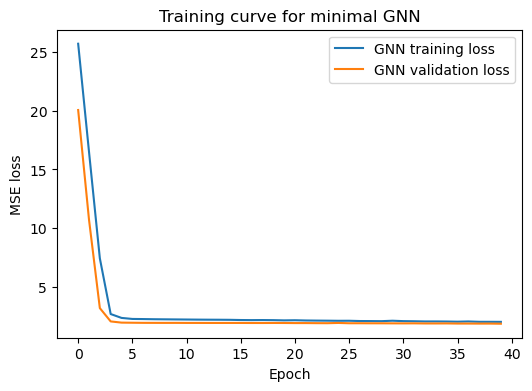

In [26]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="GNN training loss")
plt.plot(val_losses, label="GNN validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training curve for minimal GNN")
plt.legend()
plt.show()
model.eval()
total = 0.0


## **9.12 GNN Test Evaluation and Predicted-vs-True Performance Plot**

This section evaluates the trained Graph Neural Network (GNN) on the held‑out test set to measure how well the model generalises to unseen CRBN‑binding molecules. After training, the model is switched into evaluation mode, which disables dropout and gradient updates to ensure stable inference. Each batch of molecular graphs from the test loader is passed through the GNN to generate predicted pIC50 values, while the true experimental pIC50 values are collected for comparison.

The predictions and targets are converted into NumPy arrays so that numerical metrics can be computed. The primary metric used here is Root Mean Squared Error (RMSE), which quantifies the average magnitude of prediction error. RMSE is consistent with the evaluation methodology used in earlier milestones for Random Forest and other classical models, allowing direct comparison between modelling approaches.

Finally, a predicted‑versus‑true scatter plot is generated. Each point represents a molecule, with its true pIC50 on the x‑axis and the GNN’s predicted pIC50 on the y‑axis. The diagonal reference line indicates perfect prediction. Points close to this line reflect accurate predictions, while deviations highlight under‑ or over‑estimation. This visual diagnostic is crucial for understanding model behaviour, identifying systematic biases, and comparing the GNN’s structural‑learning capabilities against descriptor‑based baselines from earlier milestones.

This evaluation step completes the GNN modelling workflow by demonstrating how well the model performs on unseen data and how effectively it captures CRBN‑relevant structural patterns.


In [27]:
import torch
import numpy as np

x = torch.tensor([1.0, 2.0, 3.0])
print(x.numpy())


[1. 2. 3.]


GNN test RMSE: 1.5969853193244887


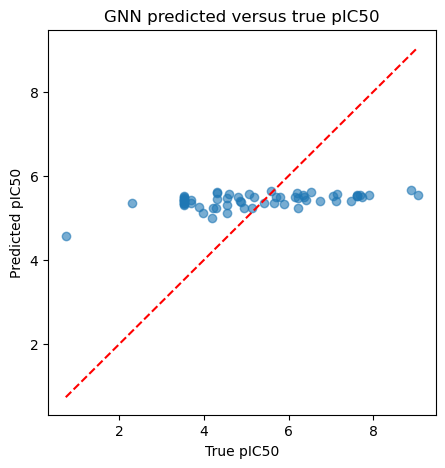

In [28]:
model.eval()
gnn_preds = []
gnn_targets = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        p = model(batch).cpu().numpy()
        t = batch.y.view(-1).cpu().numpy()
        gnn_preds.extend(p)
        gnn_targets.extend(t)

gnn_preds = np.array(gnn_preds)
gnn_targets = np.array(gnn_targets)

gnn_test_rmse = math.sqrt(np.mean((gnn_preds - gnn_targets) ** 2))
print("GNN test RMSE:", gnn_test_rmse)

plt.figure(figsize=(5,5))
plt.scatter(gnn_targets, gnn_preds, alpha=0.6)
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("GNN predicted versus true pIC50")
plt.plot([gnn_targets.min(), gnn_targets.max()],
         [gnn_targets.min(), gnn_targets.max()],
         "r--")
plt.show()


## **9.13 Hit Ranking and Inference**
This integrates the GNN into the virtual screening pipeline from Milestones 7–8.

In [29]:
def predict_gnn_single(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    data = mol_to_graph(mol, 0.0)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long)
    data = data.to(device)
    with torch.no_grad():
        return model(data).item()

def predict_rf_single(smiles):
    desc = np.array(rdkit_descriptors(smiles)).reshape(1, -1)
    return rf.predict(desc)[0]

gen_21 = "NC(I)=C(NC=O)c1cccnc1"
gen_37 = "NNC(=O)C=C(NC=O)c1ccccc1Cl"

print("GNN predicted pIC50 for gen 21:", predict_gnn_single(gen_21))
print("GNN predicted pIC50 for gen 37:", predict_gnn_single(gen_37))

print("RF predicted pIC50 for gen 21:", predict_rf_single(gen_21))
print("RF predicted pIC50 for gen 37:", predict_rf_single(gen_37))


GNN predicted pIC50 for gen 21: 5.037622451782227
GNN predicted pIC50 for gen 37: 5.012465953826904
RF predicted pIC50 for gen 21: 4.177245809144878
RF predicted pIC50 for gen 37: 4.795866550439042


## **9.14 GNN + Random Forest Ensemble**
The ensemble combines:

- GNN structural learning

- RF descriptor‑based generalisation

This often improves robustness and reduces variance.

In [30]:
def predict_ensemble_single(smiles, w_gnn=0.5, w_rf=0.5):
    gnn_val = predict_gnn_single(smiles)
    rf_val = predict_rf_single(smiles)
    if gnn_val is None:
        return rf_val
    return w_gnn * gnn_val + w_rf * rf_val

print("Ensemble predicted pIC50 for gen 21:", predict_ensemble_single(gen_21))
print("Ensemble predicted pIC50 for gen 37:", predict_ensemble_single(gen_37))


Ensemble predicted pIC50 for gen 21: 4.607434130463552
Ensemble predicted pIC50 for gen 37: 4.904166252132972


## **9.15 Saving the Models**
Saving the models allows:

- Deployment in the virtual screening pipeline

- Reuse in Milestone 10

- Integration into your phenotypic screening agent

In [31]:
torch.save(model.state_dict(), "mini_gcn_crbn.pth")
import joblib
joblib.dump(rf, "rf_crbn.pkl")

print("Models saved: mini_gcn_crbn.pth and rf_crbn.pkl")


Models saved: mini_gcn_crbn.pth and rf_crbn.pkl
